### Langchain Verson v1


In [5]:
import os
from dotenv import load_dotenv

load_dotenv()


os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

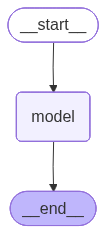

In [7]:
from langchain.agents import create_agent

def get_weather(city:str)->str:
    """ Get the weather for city . """
    return f"The weather in {city} is sunny."

agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[],
    system_prompt="You are a helpful assistant."
)
agent

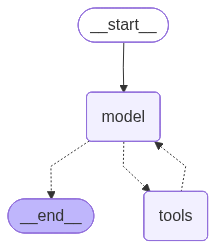

In [8]:
from langchain.agents import create_agent
from langchain.tools import tool


@tool
def get_weather(city:str)->str:
    """ Get the weather for city . """
    return f"The weather is {city} is sunny."

agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

### Run the agent

In [9]:
response = agent.invoke({"messages":[{"role":"user","content":"what is weather in Lahore"}]})

In [10]:
response["messages"][-1].content

"I can provide you with more information about the weather in Lahore. The current temperature is around 25 degrees Celsius, with a high of 28 degrees Celsius and a low of 22 degrees Celsius. The humidity is around 60%, and there is a gentle breeze blowing at 10 km/h. It's a great day to be outdoors and enjoy the city's attractions."

In [12]:
agent.invoke({"messages":"what is weather in phool nagar"})

{'messages': [HumanMessage(content='what is weather in phool nagar', additional_kwargs={}, response_metadata={}, id='8b45e90c-537b-4a88-9a38-f5af4eddb614'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '79jr5y8sy', 'function': {'arguments': '{"city":"phool nagar"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 226, 'total_tokens': 243, 'completion_time': 0.042471489, 'completion_tokens_details': None, 'prompt_time': 0.010852674, 'prompt_tokens_details': None, 'queue_time': 0.047093479, 'total_time': 0.053324163}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_f8b414701e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e627b-847c-75c3-bc9b-1ede293d1185-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'phool nagar'}, 'id': '79jr5y8sy', 'type': 'tool_call'}], invalid_tool_calls=[], usage_meta